In [1]:
import sys
sys.path.append("..")
import warnings
warnings.filterwarnings("ignore")

In [2]:
from src.color import *
from skimage.color import rgb2lab
from src.utils import *

In [3]:
import torch
from src.models import *

regression = Unet_Regression()
regression.load_state_dict(torch.load("../checkpoints/models/Unet_regression/unet_regression_epoch_500.pth"))
classification = DeepCNN()
classification.load_state_dict(torch.load("../checkpoints/models/Zhang/zhang_epoch_500.pth")['model'])
GAN = UNetGenerator()
GAN.load_state_dict(torch.load("../checkpoints/models/GAN/gan_epoch_450.pth")['G'])

<All keys matched successfully>

In [4]:
import torch
from torchvision.datasets import CIFAR10
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
dataset = CIFAR10(root="../data/raw", train=False, download=True)
class_names = dataset.classes

Files already downloaded and verified


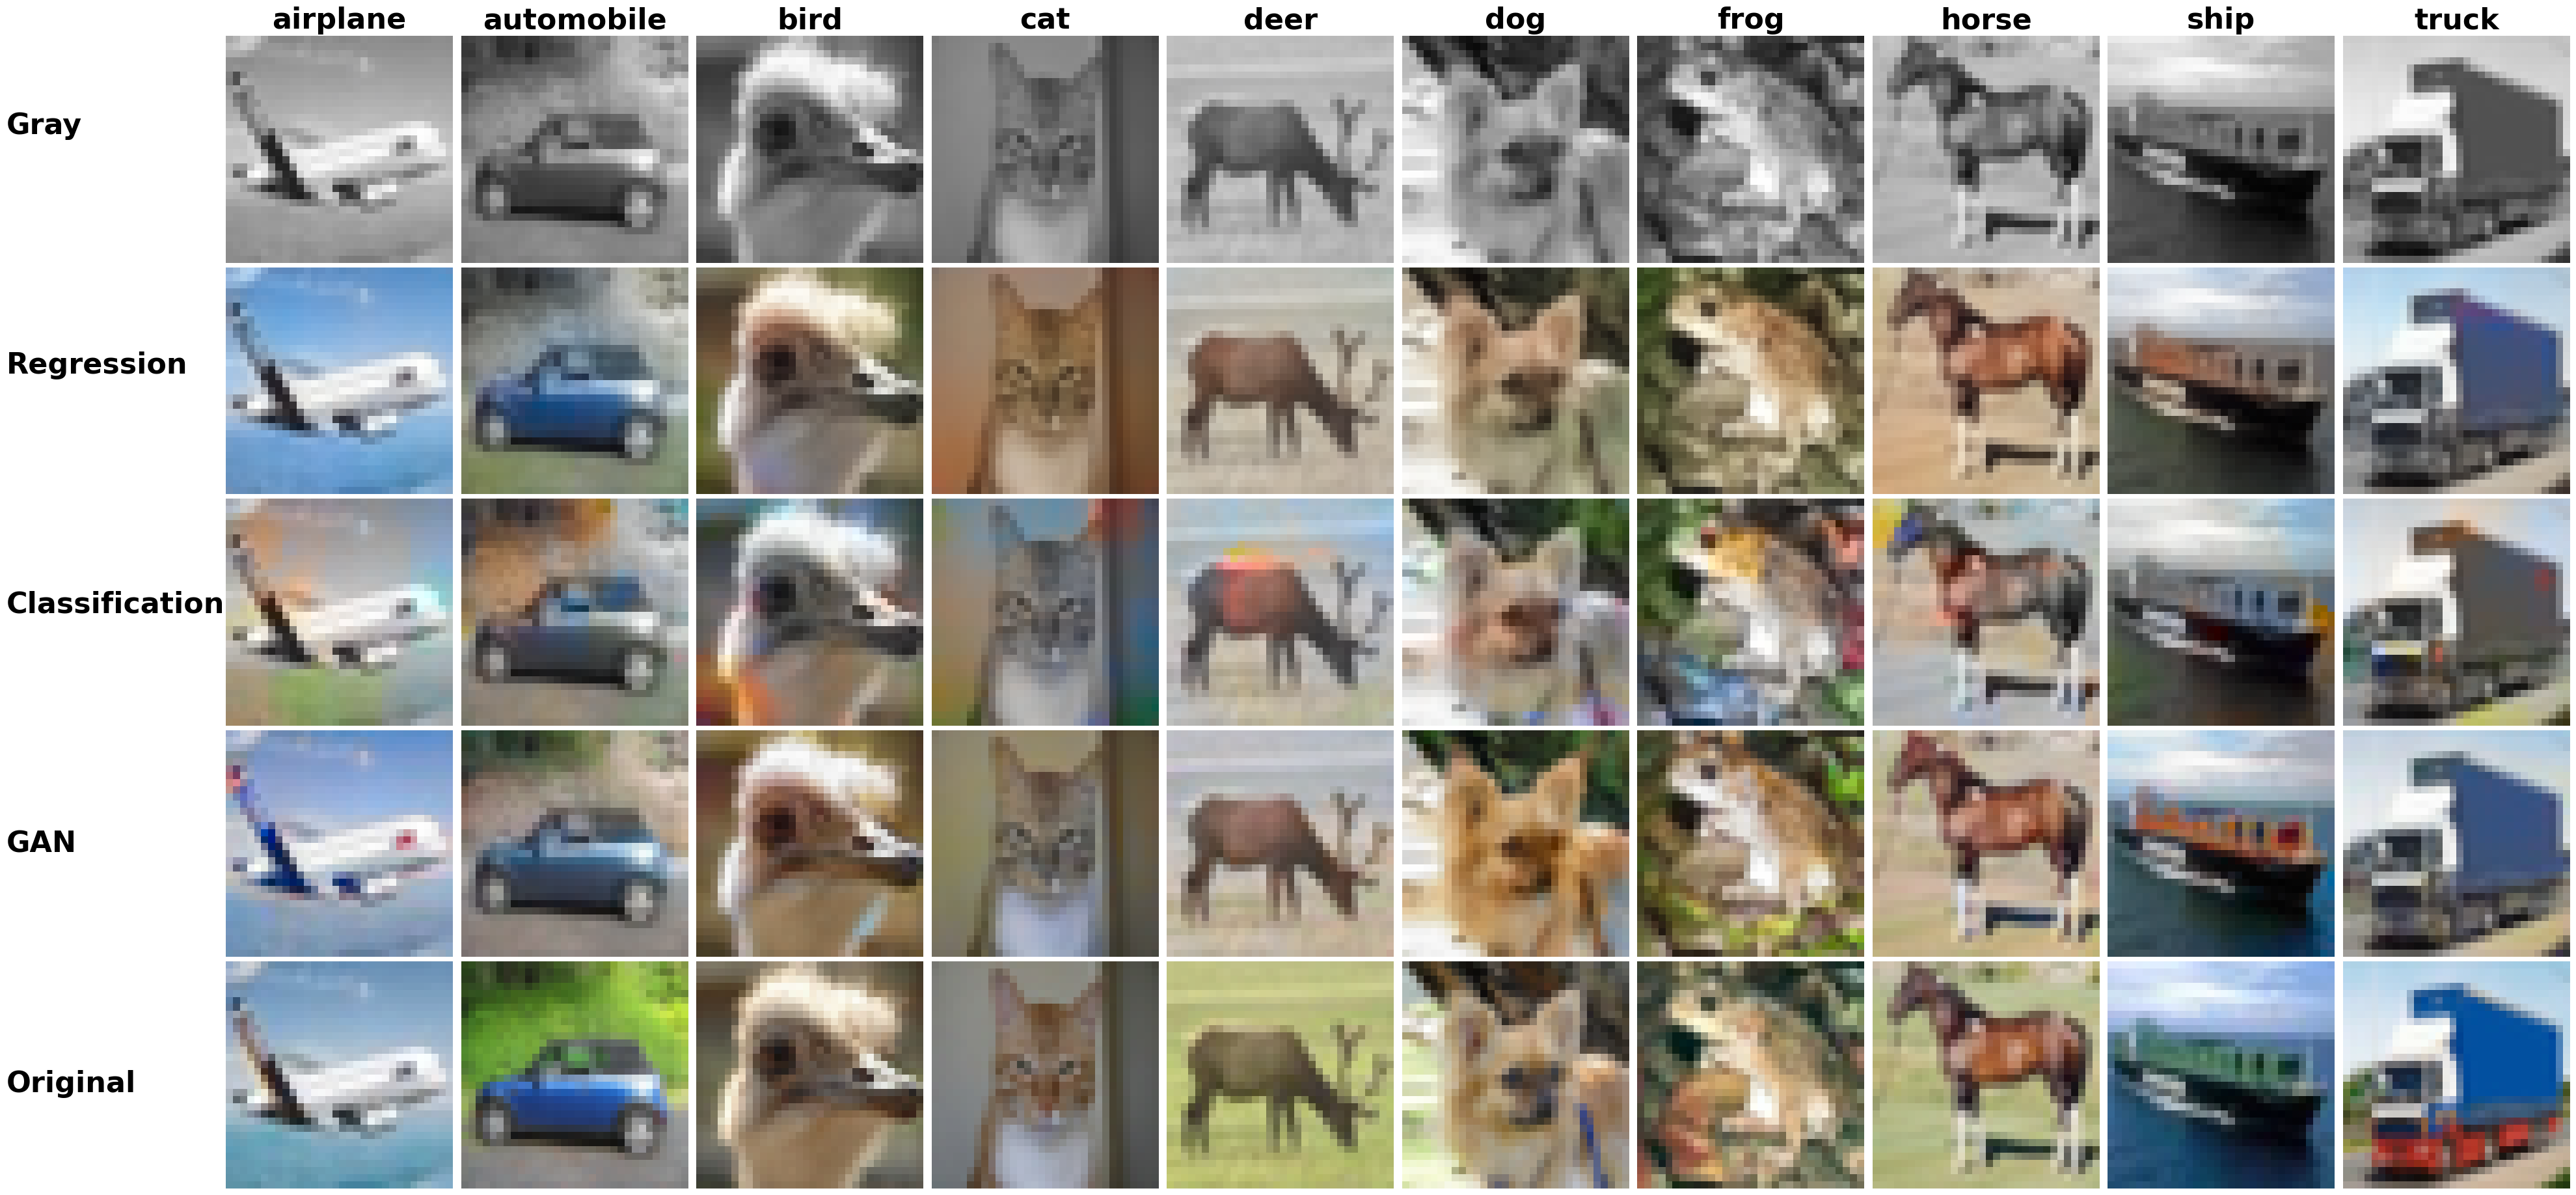

In [5]:
image_list = [dataset[560], dataset[82], dataset[1960], dataset[1274], dataset[1842], dataset[421], dataset[1081], dataset[208], dataset[1369], dataset[1881]]
fig, axes = plt.subplots(5, 10, figsize=(44, 23))

row_titles = ["Gray", "Regression", "Classification", "GAN", "Original"]

# Lấy tên class CIFAR-10
class_names = dataset.classes

# 🔥 Thêm label phía trên mỗi cột
for col in range(10):
    _, label = image_list[col]
    axes[0, col].set_title(class_names[label], fontsize=32, weight='bold', pad=8)

with torch.no_grad():
    for col in range(10):

        img, label = image_list[col]
        img_np = np.array(img)

        rgb = img_np.astype("float32") / 255.0
        lab = rgb2lab(rgb).astype("float32")

        L  = lab[..., 0:1] / 100.0
        ab = lab[..., 1:3] / 128.0

        L  = torch.from_numpy(L).permute(2,0,1).unsqueeze(0)
        ab = torch.from_numpy(ab).permute(2,0,1).unsqueeze(0)

        reg_out = regression(L)
        cls_out = classification(L)
        gan_out = GAN(L)

        outputs = [
            lab_to_rgb(L, torch.zeros_like(reg_out)),
            lab_to_rgb(L, reg_out),
            lab_to_rgb(L, soft_decode(cls_out, T=0.38)),
            lab_to_rgb(L, gan_out),
            lab_to_rgb(L, ab)
        ]

        for row in range(5):
            img_show = outputs[row].squeeze(0)
            axes[row, col].imshow(img_show)
            axes[row, col].axis("off")

# 🔥 Row titles (không dùng set_ylabel nữa)
for row in range(5):
    fig.text(
        0.004,                 # khoảng cách lề trái
        0.82 - row*0.16,     # chỉnh nếu cần
        row_titles[row],
        va='center',
        ha='left',
        fontsize=32,
        weight='bold'
    )

plt.subplots_adjust(left=0.08, wspace=0.02, hspace=0.02)
plt.show()